In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import os
import h5py
from anndata import AnnData

import scanpy as sc
import squidpy as sq
import bin2cell as b2c

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GAE, GCNConv

import networkx as nx
from scipy.spatial import Delaunay
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import umap
import sklearn
import sklearn.neighbors
import scipy.sparse as sp

## Helper functions

In [2]:
# From SpaGRA paper
def prefilter_genes(adata, min_cells=3):
    """
    Filters genes to retain only those expressed in at least `min_cells` cells.
    """
    sc.pp.filter_genes(adata, min_cells=min_cells)
    return adata

def Cal_Spatial_Net(adata, rad_cutoff=None, k_cutoff=None, model='Radius', Spatial_uns="Spatial_Net"):
    """
    Construct the spatial neighbor network for an AnnData object.
    
    Parameters:
        adata       : AnnData object with spatial coordinates stored in adata.obsm['spatial']
        rad_cutoff  : If using 'Radius' model, spots within this Euclidean distance will be connected
        k_cutoff    : If using 'KNN' model, the number of nearest neighbors for each spot (not used here)
        model       : Either 'Radius' or 'KNN'. Default is 'Radius'.
        Spatial_uns : The key under which the resulting spatial network (DataFrame) is stored in adata.uns.
    
    The function calculates pairwise distances based on the spatial coordinates and then builds a DataFrame 
    of neighbor connections (edges) with columns 'Cell1', 'Cell2', and 'Distance'.
    """
    print('------Calculating spatial graph...')
    assert (model in ['Radius', 'KNN']), "Model must be 'Radius' or 'KNN'"

    # Create a DataFrame from the spatial coordinates.
    coor = pd.DataFrame(adata.obsm['spatial'])
    coor.index = adata.obs.index
    coor.columns = ['imagerow', 'imagecol']

    if model == 'Radius':
        nbrs = sklearn.neighbors.NearestNeighbors(radius=rad_cutoff).fit(coor)
        distances, indices = nbrs.radius_neighbors(coor, return_distance=True)
        KNN_list = []
        for it in range(indices.shape[0]):
            # Each row gives a set of neighbors (including self)
            # The zip below creates tuples (current_index, neighbor_index, distance)
            KNN_list.append(pd.DataFrame(zip([it] * indices[it].shape[0], indices[it], distances[it])))
    elif model == 'KNN':
        nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=k_cutoff + 1).fit(coor)
        distances, indices = nbrs.kneighbors(coor)
        KNN_list = []
        for it in range(indices.shape[0]):
            KNN_list.append(pd.DataFrame(zip([it] * indices[it].shape[0], indices[it, :], distances[it, :])))
    
    # Combine all neighbor data into one DataFrame.
    KNN_df = pd.concat(KNN_list)
    KNN_df.columns = ['Cell1', 'Cell2', 'Distance']
    
    # Remove self-loops (distance == 0).
    Spatial_Net = KNN_df.loc[KNN_df['Distance'] > 0,].copy()
    
    # Map numerical indices back to cell (spot) names.
    id_cell_trans = dict(zip(range(coor.shape[0]), coor.index))
    Spatial_Net['Cell1'] = Spatial_Net['Cell1'].map(id_cell_trans)
    Spatial_Net['Cell2'] = Spatial_Net['Cell2'].map(id_cell_trans)
    
    adata.uns[Spatial_uns] = Spatial_Net
    print(f"Spatial network with {len(Spatial_Net)} edges stored in adata.uns['{Spatial_uns}']")
    return adata

def Transfer_Data(adata):
    """
    Convert an AnnData object with a spatial network in adata.uns['Spatial_Net'] into a graph representation.
    
    Returns
    -------
    G    : a sparse COO-format adjacency matrix (with self-loops added)
    X    : the gene expression feature matrix (as a dense NumPy array)
    """
    # Copy the spatial network DataFrame
    G_df = adata.uns['Spatial_Net'].copy()
    
    # Map the cell (spot) names to integer indices
    cells = np.array(adata.obs_names)
    cells_id_tran = dict(zip(cells, range(len(cells))))
    G_df['Cell1'] = G_df['Cell1'].map(cells_id_tran)
    G_df['Cell2'] = G_df['Cell2'].map(cells_id_tran)
    
    # Create a sparse adjacency matrix from the edge list; note that we are using unit weights.
    n = adata.n_obs
    G = sp.coo_matrix((np.ones(G_df.shape[0]), (G_df['Cell1'], G_df['Cell2'])), shape=(n, n))
    # Add self-loops so that every node is connected to itself
    G = G + sp.eye(n)
    
    # Get the feature matrix from adata.X.
    # If adata.X is sparse, convert it to dense.
    if hasattr(adata.X, "todense"):
        X = np.array(adata.X.todense())
    else:
        X = np.array(adata.X)
    
    return G, X

# Visium data

In [3]:
# # Path v2 data
# spatial_dir = "../data/v2_data"

# # Read Visium dataset
# adata_v2 = sc.read_visium(path=spatial_dir)

# load the pre-processed dataset from Squidpy
img_v2 = sq.datasets.visium_hne_image()
adata_v2 = sq.datasets.visium_hne_adata()

utils.py (494): The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
__init__.py (55): `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.


In [4]:
# Print the summary of the AnnData object
print(adata_v2)

# Check the first few rows of metadata
print(adata_v2.obs.head())

# Check the first few rows of gene information
print(adata_v2.var.head())

# Check unique gene counts and feature types
print(adata_v2.var['feature_types'].value_counts())

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
                    in_tissue  array_row  array_col  n_genes_by_counts  \
AAACAAGTATCTCCCA-1          1         50    

# Visium HD data

In [5]:
# Load Visium HD dataset using bin2cell
### Load Data

# Define paths to required files
path = "../data/mouse_hd_data/binned_outputs_mousebrain_hd/square_008um/"
source_image_path = "../data/mouse_hd_data/Visium_HD_Mouse_Brain_tissue_image.tif"
spaceranger_image_path = "../data/mouse_hd_data/spatial_mousebrain_hd"

# Load data
adata_hd = b2c.read_visium(path, 
                        source_image_path = source_image_path, 
                        spaceranger_image_path = spaceranger_image_path
                       )
adata_hd.var_names_make_unique()

anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [6]:
# Summary of observations (cells) and variables (genes)
print(adata_hd)

# Check the first few rows of metadata
print(adata_hd.obs.head())

# Check the first few rows of gene information
print(adata_hd.var.head())

# Check unique gene counts and feature types
print(adata_hd.var['feature_types'].value_counts())

AnnData object with n_obs × n_vars = 393543 × 19059
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
                       in_tissue  array_row  array_col
s_008um_00301_00321-1          1        301        321
s_008um_00602_00290-1          1        602        290
s_008um_00515_00112-1          1        515        112
s_008um_00383_00696-1          1        383        696
s_008um_00526_00291-1          1        526        291
                  gene_ids    feature_types genome
Xkr4    ENSMUSG00000051951  Gene Expression   mm10
Rp1     ENSMUSG00000025900  Gene Expression   mm10
Sox17   ENSMUSG00000025902  Gene Expression   mm10
Lypla1  ENSMUSG00000025903  Gene Expression   mm10
Tcea1   ENSMUSG00000033813  Gene Expression   mm10
Gene Expression    19059
Name: feature_types, dtype: int64


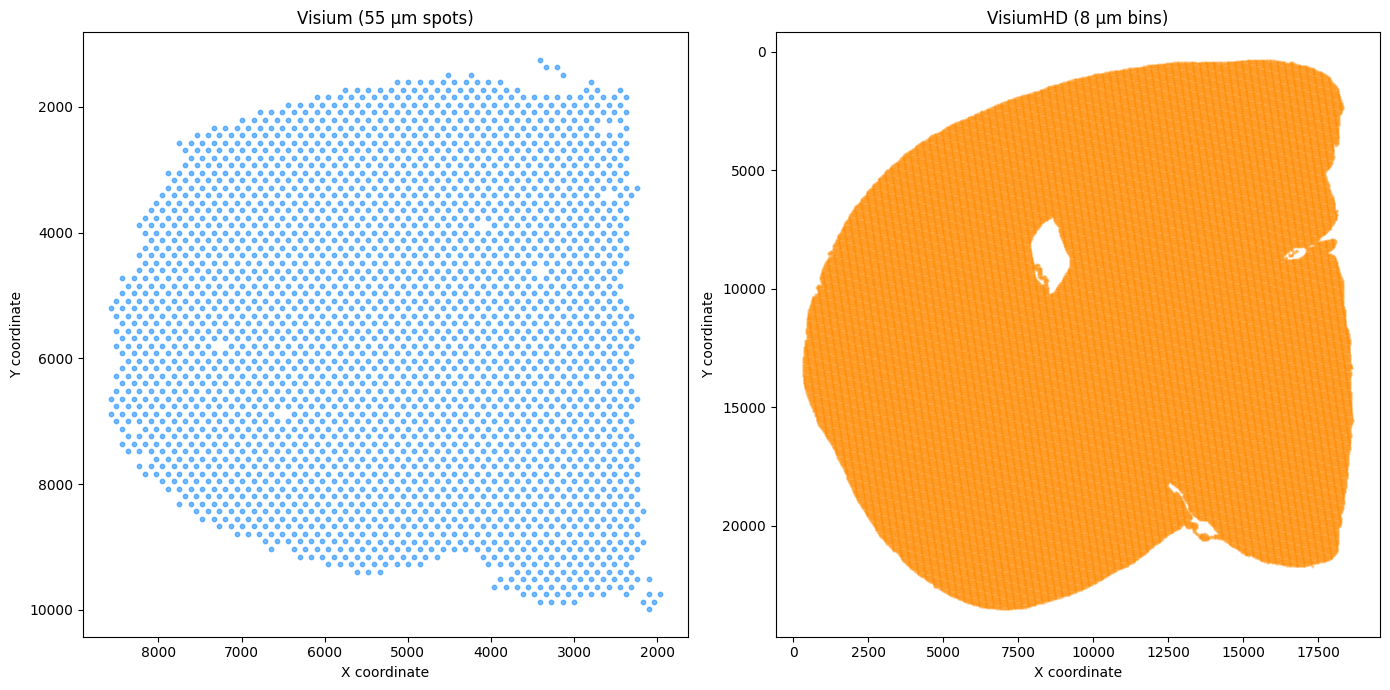

In [7]:
# Get Visium spatial coordinates
coords_v2 = adata_v2.obsm["spatial"]
coords_hd = adata_hd.obsm["spatial"]

# Plot both spatial layouts side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

# Visium (55 µm spots)
axs[0].scatter(coords_v2[:, 0], coords_v2[:, 1], c='dodgerblue', s=10, alpha=0.6)
axs[0].invert_yaxis()
axs[0].invert_xaxis() 
axs[0].set_title("Visium (55 µm spots)")
axs[0].set_xlabel("X coordinate")
axs[0].set_ylabel("Y coordinate")

# VisiumHD (8 µm bins)
axs[1].scatter(coords_hd[:, 0], coords_hd[:, 1], c='darkorange', s=0.1, alpha=0.5)
axs[1].invert_yaxis()
axs[1].set_title("VisiumHD (8 µm bins)")
axs[1].set_xlabel("X coordinate")
axs[1].set_ylabel("Y coordinate")

plt.tight_layout()
plt.show()

## Identify the Common Gene  & Subset Each AnnData Object to the Common Gene Set

In [8]:
adata_v2.var_names_make_unique()
prefilter_genes(adata_v2, min_cells=3)
sc.pp.highly_variable_genes(adata_v2, flavor="seurat_v3", n_top_genes=1000)
sc.pp.normalize_per_cell(adata_v2)
sc.pp.log1p(adata_v2)

adata_hd.var_names_make_unique()
prefilter_genes(adata_hd, min_cells=3)
sc.pp.highly_variable_genes(adata_hd, flavor="seurat_v3", n_top_genes=1000)
sc.pp.normalize_per_cell(adata_hd)
sc.pp.log1p(adata_hd)

genes_v2 = adata_v2.var_names
genes_hd = adata_hd.var_names

# Compute the intersection (common genes between both datasets)
common_genes = np.intersect1d(genes_v2, genes_hd)
print("Number of common genes:", len(common_genes))

# Subset and copy the datasets for safety
adata_v2_subset = adata_v2[:, common_genes].copy()
adata_hd_subset = adata_hd[:, common_genes].copy()

print("Visium v2 subset:", adata_v2_subset)
print("Visium HD subset:", adata_hd_subset)

_highly_variable_genes.py (62): `flavor='seurat_v3'` expects raw count data, but non-integers were found.


Number of common genes: 14842
Visium v2 subset: AnnData object with n_obs × n_vars = 2688 × 14842
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap', 'log1p'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
Visium HD subset: AnnData object with n_obs × n_vars = 393543

## Produce spatial networks for Visium v2 & Visium HD

In [9]:
# Use a radius cutoff of 400 pixels (or units) for the Visium v2 data
Cal_Spatial_Net(adata_v2_subset, rad_cutoff=400)

------Calculating spatial graph...
Spatial network with 75928 edges stored in adata.uns['Spatial_Net']


AnnData object with n_obs × n_vars = 2688 × 14842
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap', 'log1p', 'Spatial_Net'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [10]:
adata_hd_subset

AnnData object with n_obs × n_vars = 393543 × 14842
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'

In [11]:
# Process Data in Chunks
## processing the data in smaller chunks rather than all at once

# def Cal_Spatial_Net_chunked(adata, rad_cutoff, batch_size=100000, Spatial_uns="Spatial_Net"):
#     print('------Calculating spatial graph in chunks...')
#     coor = pd.DataFrame(adata.obsm['spatial'])
#     coor.index = adata.obs.index
#     coor.columns = ['imagerow', 'imagecol']
    
#     n = coor.shape[0]
#     all_edges = []
#     for start in range(0, n, batch_size):
#         end = min(n, start + batch_size)
#         # Build a model on the entire dataset if possible, but query only a batch
#         nbrs = sklearn.neighbors.NearestNeighbors(radius=rad_cutoff).fit(coor)
#         distances, indices = nbrs.radius_neighbors(coor.iloc[start:end], return_distance=True)
#         for idx, (dists, inds) in enumerate(zip(distances, indices)):
#             cur_idx = start + idx
#             for d, i in zip(dists, inds):
#                 if d > 0:
#                     all_edges.append((cur_idx, i, d))
#         print(f"Processed {end} / {n} points")
    
#     spatial_net = pd.DataFrame(all_edges, columns=['Cell1', 'Cell2', 'Distance'])
#     id_cell_trans = dict(zip(range(coor.shape[0]), coor.index))
#     spatial_net['Cell1'] = spatial_net['Cell1'].map(id_cell_trans)
#     spatial_net['Cell2'] = spatial_net['Cell2'].map(id_cell_trans)
#     adata.uns[Spatial_uns] = spatial_net
#     print(f"Spatial network with {len(spatial_net)} edges stored in adata.uns['{Spatial_uns}']")
#     return adata

# # Use the chunked version for Visium HD
# Cal_Spatial_Net_chunked(adata_hd, rad_cutoff=150, batch_size=100000)

In [12]:
# Subsampling the data
sample_idx = np.random.choice(adata_hd_subset.obs_names, size=20000, replace=False)
adata_hd_subset = adata_hd_subset[sample_idx].copy()
Cal_Spatial_Net(adata_hd_subset, rad_cutoff=150)

------Calculating spatial graph...
Spatial network with 89476 edges stored in adata.uns['Spatial_Net']


AnnData object with n_obs × n_vars = 20000 × 14842
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p', 'Spatial_Net'
    obsm: 'spatial'

## Converting the Spatial Networks to Graphs and Features

In [13]:
# For Visium v2 data
G_v2, X_v2 = Transfer_Data(adata_v2_subset)
print("Visium v2: Adjacency shape:", G_v2.shape, "Feature matrix shape:", X_v2.shape)

# For Visium HD subset 
G_hd, X_hd = Transfer_Data(adata_hd_subset)
print("Visium HD: Adjacency shape:", G_hd.shape, "Feature matrix shape:", X_hd.shape)

Visium v2: Adjacency shape: (2688, 2688) Feature matrix shape: (2688, 14842)
Visium HD: Adjacency shape: (20000, 20000) Feature matrix shape: (20000, 14842)


## Dual Graph Convolutional Autoencoder (Dual GCAE)

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 1) GRADIENT REVERSAL LAYER FOR ADVERSARIAL TRAINING
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.lambd, None

def grad_reverse(x, lambd=1.0):
    return GradReverse.apply(x, lambd)
    
# 2) GRAPH CONVOLUTION AND ENCODER WITH BATCHNORM
class GraphConv(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        nn.init.xavier_uniform_(self.weight)
    def forward(self, X, A):
        # X: [N, in_features], A: [N, N]
        support = X @ self.weight         # [N, out_features]
        return A @ support                # [N, out_features]

class GCAE_Encoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, latent_dim):
        super().__init__()
        self.gc1 = GraphConv(in_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.gc2 = GraphConv(hidden_dim, latent_dim)
        self.bn2 = nn.BatchNorm1d(latent_dim)
        self.act = nn.LeakyReLU(0.2)
    def forward(self, X, A):
        h = self.gc1(X, A)                # [N, hidden_dim]
        h = self.bn1(h)                   # batch‐norm
        h = self.act(h)
        z = self.gc2(h, A)                # [N, latent_dim]
        z = self.bn2(z)                   # batch‐norm
        z = self.act(z)
        return z                          # [N, latent_dim]
        
# 3) SHARED JOINT GCAE
def decode(Z):
    """Inner‐product decoder + sigmoid"""
    return torch.sigmoid(Z @ Z.t())

class JointGCAE(nn.Module):
    def __init__(self, in_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = GCAE_Encoder(in_dim, hidden_dim, latent_dim)
    def forward(self, X_v2, A_v2, X_hd, A_hd):
        z_v2 = self.encoder(X_v2, A_v2)    # [N_v2, L]
        z_hd = self.encoder(X_hd, A_hd)    # [N_hd, L]
        Ahat_v2 = decode(z_v2)             # [N_v2, N_v2]
        Ahat_hd = decode(z_hd)             # [N_hd, N_hd]
        return z_v2, z_hd, Ahat_v2, Ahat_hd

# 4) DOMAIN CLASSIFIER FOR ADVERSARIAL ALIGNMENT
class DomainClassifier(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, latent_dim//2),
            nn.ReLU(),
            nn.Linear(latent_dim//2, 1),
            nn.Sigmoid()
        )
    def forward(self, z, lambd):
        # apply gradient reversal
        z_rev = grad_reverse(z, lambd)
        return self.net(z_rev).squeeze()   # [N]
        
# Adjacency matrices
A_v2 = torch.tensor(G_v2.todense(), dtype=torch.float32, device=device)
A_hd = torch.tensor(G_hd.todense(), dtype=torch.float32, device=device)

# Feature matrices
X_v2_tensor = torch.tensor(X_v2, dtype=torch.float32, device=device)
X_hd_tensor = torch.tensor(X_hd, dtype=torch.float32, device=device)

# 5) INSTANTIATE MODELS & OPTIMIZERS
D       = X_v2_tensor.shape[1]     # input feature dim (common genes)
H       = 128                      # hidden dim
L       = 32                       # latent dim
λ_adv   = 0.1                      # adversarial weight
lr      = 1e-3
epochs  = 200

model       = JointGCAE(D, H, L).to(device)
domain_clf  = DomainClassifier(L).to(device)

opt_model   = torch.optim.Adam(model.parameters(), lr=lr)
opt_domain  = torch.optim.Adam(domain_clf.parameters(), lr=lr)

# 6) TRAINING LOOP
for epoch in range(1, epochs+1):
    model.train()
    domain_clf.train()
    opt_model.zero_grad()
    opt_domain.zero_grad()

    # Forward through GCAE
    z_v2, z_hd, Ahat_v2, Ahat_hd = model(X_v2_tensor, A_v2, X_hd_tensor, A_hd)

    # 1) Reconstruction losses
    loss_v2 = F.binary_cross_entropy(Ahat_v2, A_v2)
    loss_hd = F.binary_cross_entropy(Ahat_hd, A_hd)
    loss_recon = loss_v2 + loss_hd

    # 2) Domain‐adversarial loss
    z_all = torch.cat([z_v2, z_hd], dim=0)
    labels_domain = torch.cat([
        torch.zeros(z_v2.size(0), device=device),
        torch.ones (z_hd.size(0), device=device)
    ])
    preds_domain = domain_clf(z_all, λ_adv)
    loss_domain  = F.binary_cross_entropy(preds_domain, labels_domain)

    # 3) Total loss
    loss = loss_recon + loss_domain
    loss.backward()
    opt_model.step()
    opt_domain.step()

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Recon: {(loss_recon.item()):.4f} "
              f"| Domain: {(loss_domain.item()):.4f} | Total: {(loss.item()):.4f}")

# 7) EXTRACT FINAL LATENT EMBEDDINGS
model.eval()
with torch.no_grad():
    z_v2, z_hd, _, _ = model(X_v2_tensor, A_v2, X_hd_tensor, A_hd)

z_v2_np = z_v2.cpu().numpy()
z_hd_np = z_hd.cpu().numpy()

print("Done — batch‐invariant joint embeddings ready for downstream analysis.")

Epoch 001 | Recon: 9.0074 | Domain: 0.6235 | Total: 9.6310
Epoch 010 | Recon: 8.3407 | Domain: 0.6077 | Total: 8.9484
Epoch 020 | Recon: 6.2493 | Domain: 0.6036 | Total: 6.8529
Epoch 030 | Recon: 4.9238 | Domain: 0.6040 | Total: 5.5278
Epoch 040 | Recon: 4.1009 | Domain: 0.5995 | Total: 4.7004
Epoch 050 | Recon: 3.5983 | Domain: 0.5919 | Total: 4.1902
Epoch 060 | Recon: 3.2083 | Domain: 0.5829 | Total: 3.7912
Epoch 070 | Recon: 2.9082 | Domain: 0.5723 | Total: 3.4805
Epoch 080 | Recon: 2.6848 | Domain: 0.5610 | Total: 3.2458
Epoch 090 | Recon: 2.5186 | Domain: 0.5489 | Total: 3.0675
Epoch 100 | Recon: 2.4008 | Domain: 0.5362 | Total: 2.9370
Epoch 110 | Recon: 2.3064 | Domain: 0.5231 | Total: 2.8295
Epoch 120 | Recon: 2.2028 | Domain: 0.5100 | Total: 2.7128
Epoch 130 | Recon: 2.1394 | Domain: 0.4971 | Total: 2.6365
Epoch 140 | Recon: 2.0983 | Domain: 0.4838 | Total: 2.5822
Epoch 150 | Recon: 2.0424 | Domain: 0.4706 | Total: 2.5130
Epoch 160 | Recon: 1.9875 | Domain: 0.4581 | Total: 2.44

## Extract Latent Representations

umap_.py (1952): n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


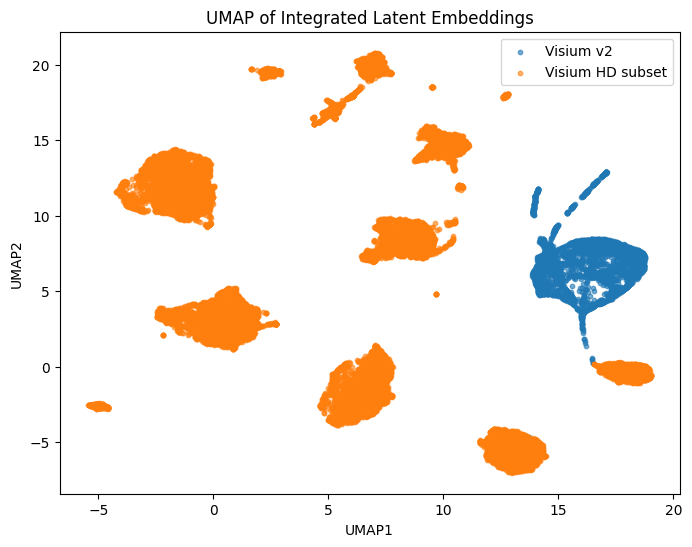

In [40]:
# Concatenate the latent representations from both datasets.
combined_z = np.concatenate([z_v2_np, z_hd_np], axis=0)

# Fit UMAP for 2D visualization.
umap_reducer = umap.UMAP(n_components=2, random_state=42)
umap_embedding = umap_reducer.fit_transform(combined_z)

# Create labels for the two groups.
labels = np.concatenate([np.zeros(z_v2_np.shape[0]), np.ones(z_hd_np.shape[0])])
group_names = {0: "Visium v2", 1: "Visium HD subset"}

# Plot the UMAP embedding.
plt.figure(figsize=(8, 6))
for group in np.unique(labels):
    idx = labels == group
    plt.scatter(umap_embedding[idx, 0], umap_embedding[idx, 1],
                label=group_names[group], alpha=0.6, s=10)
plt.title("UMAP of Integrated Latent Embeddings")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend()
plt.show()

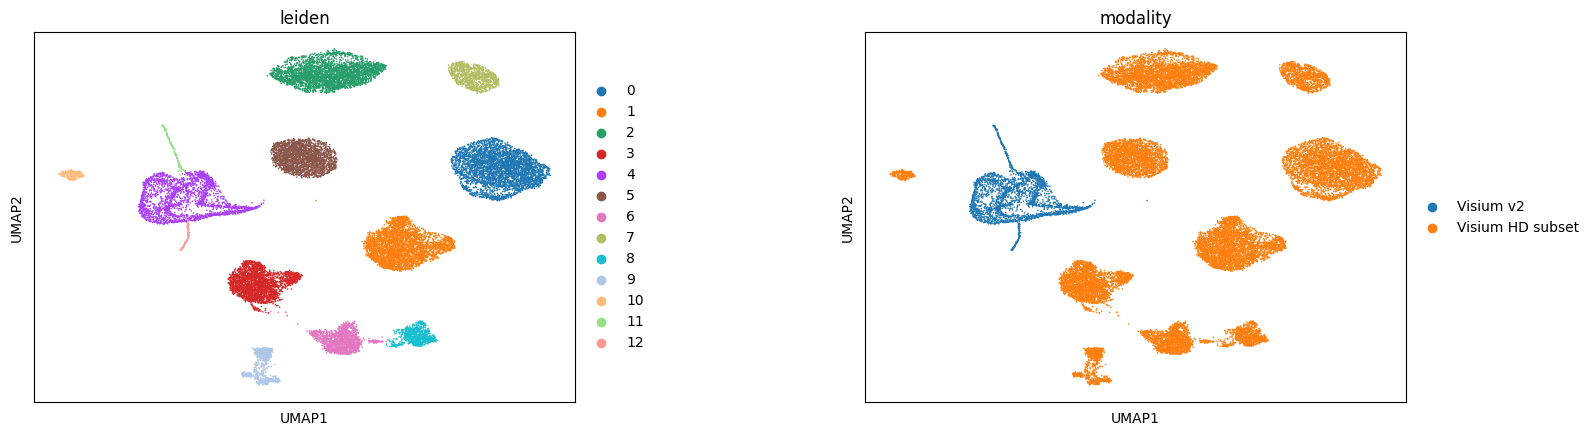

In [41]:
# Create an AnnData object for the combined latent embeddings.
combined_adata = sc.AnnData(X=combined_z)
# Add group labels so you can later deconvolve the groups if needed.
combined_adata.obs['modality'] = pd.Categorical(labels, categories=[0, 1], 
                                                ordered=True).rename_categories(group_names)

# Compute a neighbor graph based on the latent space.
sc.pp.neighbors(combined_adata, use_rep='X', n_neighbors=100)

# Run Leiden clustering.
sc.tl.leiden(combined_adata, resolution=0.5)
# Run UMAP for visualization (if not already done).
sc.tl.umap(combined_adata)

# Plot the UMAP colored by Leiden clusters.
sc.pl.umap(combined_adata, color=['leiden', 'modality'], wspace=0.4)

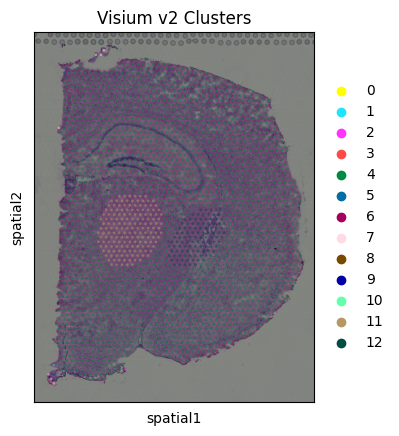

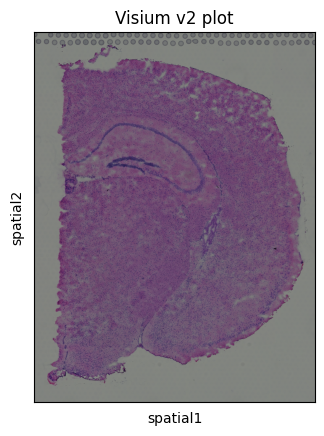

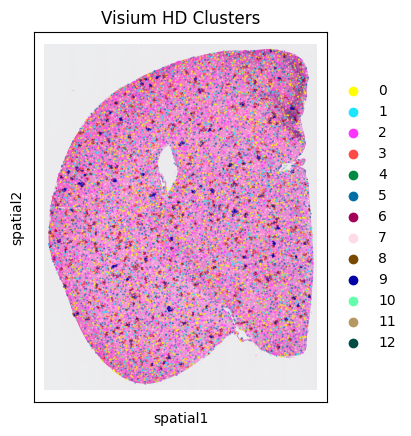

In [44]:
# Get the number of spots in each dataset.
n_v2 = adata_v2_subset.n_obs
n_hd = adata_hd_subset.n_obs

# Split the clusters
clusters_v2 = combined_adata.obs['leiden'].iloc[:n_v2].values
clusters_hd = combined_adata.obs['leiden'].iloc[n_v2:].values

adata_v2_subset.obs['cluster'] = pd.Categorical(clusters_v2)
adata_hd_subset.obs['cluster'] = pd.Categorical(clusters_hd)

# Visualize Visium v2 spatial plot with smaller and transparent points.
sc.pl.spatial(adata_v2_subset, color='cluster', title='Visium v2 Clusters', size=0.8, alpha=0.5)  
sc.pl.spatial(adata_v2_subset, title='Visium v2 plot')  
# Visualize Visium HD subset spatial plot with smaller and transparent points.
sc.pl.spatial(adata_hd_subset, color='cluster', title='Visium HD Clusters', size=4, alpha=0.6)

Very Low Scores: cells across clusters are not strongly separated from each other